# CSDS119: Computer Vision and Image Processing
## LAB 1: Understanding Digital Images Using Python
**Platform:** Google Colab / Jupyter Notebook

### Tasks:
- Read an image in Python.
- Understand that an image is a NumPy matrix.
- Identify image dimensions, channels and bit depth.
- Access and modify pixels.
- Perform basic intensity transformations.
- Visualize histograms and binary images.
- Understand the effect of resizing and noise.
- Apply basic mean and median filtering.


## Part 1 — Setup
Run the following cell to import the required libraries.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('Libraries imported successfully!')


Libraries imported successfully!


## Part 2 — Upload and Read an Image
The next cell allows you to upload an image directly in Google Colab. In Jupyter, you may instead place an image in the same folder as this notebook.


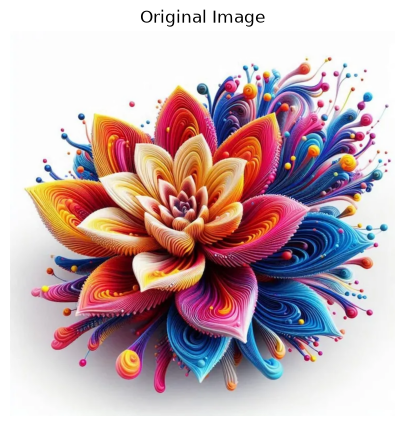

In [2]:
# Works directly in Google Colab or Jupyter Notebook
try:
    from google.colab import files
    uploaded = files.upload()
    filename = next(iter(uploaded))
except ImportError:
    filename = 'sample.jpg'

img = cv2.imread(filename)
if img is None:
    raise FileNotFoundError('Image could not be read. Check the filename/path.')

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()


### Think Before Moving Ahead
**Question:** Is Python storing this image as a photograph or as numbers?


## Part 3 — Explore Image Properties


In [3]:
print('Data type:', type(img))
print('Shape:', img.shape)
print('Data type of pixels:', img.dtype)
print('Minimum pixel value:', img.min())
print('Maximum pixel value:', img.max())


Data type: <class 'numpy.ndarray'>
Shape: (740, 740, 3)
Data type of pixels: uint8
Minimum pixel value: 0
Maximum pixel value: 255


### Understand the Output
For a color image with shape `(height, width, 3)`:
- **Height** = number of rows
- **Width** = number of columns
- **3** = color channels
- `uint8` means each channel is represented using 8 bits

For an 8-bit image: $$L = 2^8 = 256$$ so the intensity range is normally 0 to 255.

**Think:** Why can't a `uint8` image store the value 300?


## Part 4 — Convert the Image to Grayscale


Color shape: (740, 740, 3)
Grayscale shape: (740, 740)


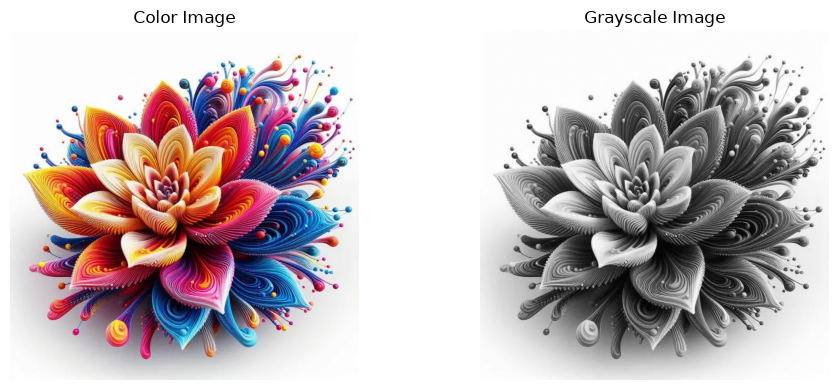

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Color Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.tight_layout()
plt.show()

print('Color shape:', img.shape)
print('Grayscale shape:', gray.shape)


**Think:** Why did the third dimension disappear after converting to grayscale?


## Part 5 — See the Image as a Matrix
A digital grayscale image is a matrix of intensity values.


In [5]:
# Grayscale image as a 2D matrix of pixel intensity values
print('Grayscale image slice (top-left 5x5 matrix):\n', gray[:5, :5])


Grayscale image slice (top-left 5x5 matrix):
 [[254 254 254 254 254]
 [254 254 254 254 254]
 [254 254 254 254 254]
 [254 254 254 254 254]
 [254 254 254 254 254]]


### Pixel Access
Remember: NumPy uses `[row, column]`, i.e. `[y, x]`.


In [6]:
# Access pixel intensity at row y=100, column x=100
y, x = 100, 100
print(f'Pixel value at (row={y}, col={x}): {gray[y, x]}')


Pixel value at (row=100, col=100): 253


## Part 6 — Modify One Pixel
The following experiment changes only one pixel to white.


Original pixel value at (100, 100): 253
Modified pixel value at (100, 100): 255


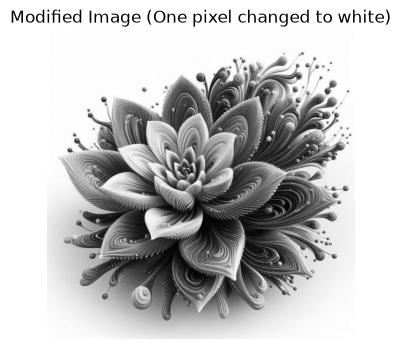

In [7]:
modified_img = gray.copy()
modified_img[100, 100] = 255

print('Original pixel value at (100, 100):', gray[100, 100])
print('Modified pixel value at (100, 100):', modified_img[100, 100])

plt.figure(figsize=(5, 4))
plt.imshow(modified_img, cmap='gray')
plt.title('Modified Image (One pixel changed to white)')
plt.axis('off')
plt.show()


**Think:** Only one number changed. Why is the change difficult to notice in the complete image?


## Part 7 — Intensity Transformation: Negative
For an 8-bit grayscale image: $$s = 255 - r$$ where $r$ is the input intensity and $s$ is the output intensity.


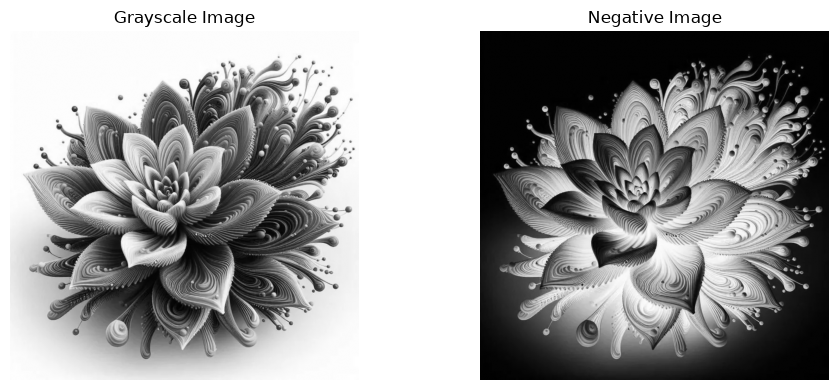

In [8]:
negative_img = 255 - gray

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_img, cmap='gray')
plt.title('Negative Image')
plt.axis('off')

plt.tight_layout()
plt.show()


**Think:** Why does black become white and white become black?


## Part 8 — Brightness Transformation
Increase brightness by 50: $$s = r + 50$$ Because an 8-bit image cannot contain values above 255, clipping is required.


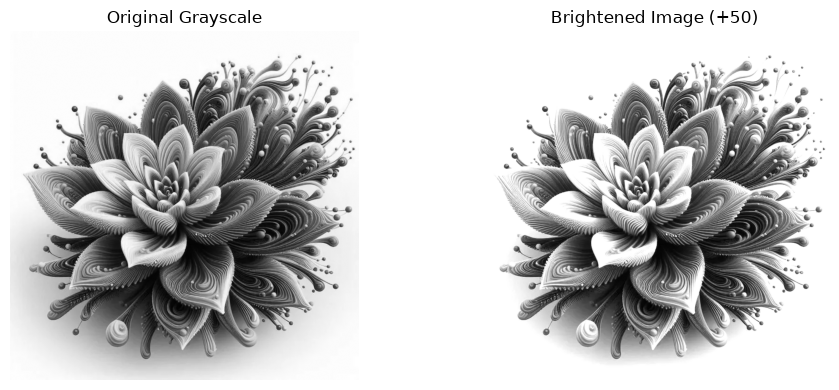

In [9]:
bright_img = np.clip(gray.astype(np.int16) + 50, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bright_img, cmap='gray')
plt.title('Brightened Image (+50)')
plt.axis('off')

plt.tight_layout()
plt.show()


**Think:** Why is `np.clip()` necessary here?


## Part 9 — Thresholding
A simple threshold transforms a grayscale image into a binary image:
$$s(x,y) = \begin{cases} 255, & r(x,y) > T \\ 0, & r(x,y) \le T \end{cases}$$


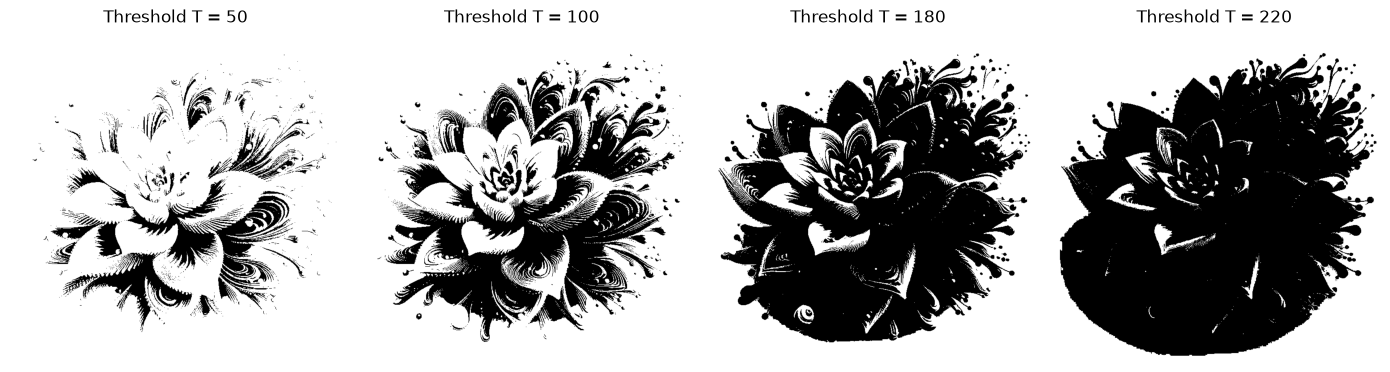

In [10]:
thresholds = [50, 100, 180, 220]

plt.figure(figsize=(14, 4))
for idx, T in enumerate(thresholds, 1):
    binary_img = np.where(gray > T, 255, 0).astype(np.uint8)
    plt.subplot(1, 4, idx)
    plt.imshow(binary_img, cmap='gray')
    plt.title(f'Threshold T = {T}')
    plt.axis('off')

plt.tight_layout()
plt.show()


### Investigation
Change $T$ to 50, 100, 180 and 220. Observe what happens.

**Think:** Why does changing the threshold change the visible object/region?


## Part 10 — Histogram


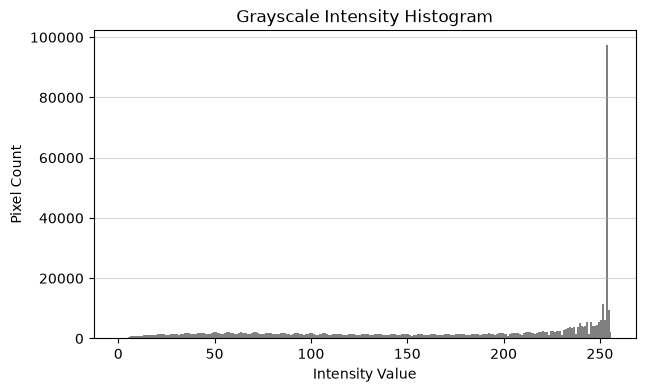

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(gray.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Grayscale Intensity Histogram')
plt.xlabel('Intensity Value')
plt.ylabel('Pixel Count')
plt.grid(axis='y', alpha=0.5)
plt.show()


**Think:** Without looking at the image, what information can the histogram tell you about the distribution of pixel intensities?


## Part 11 — Cropping and Resizing


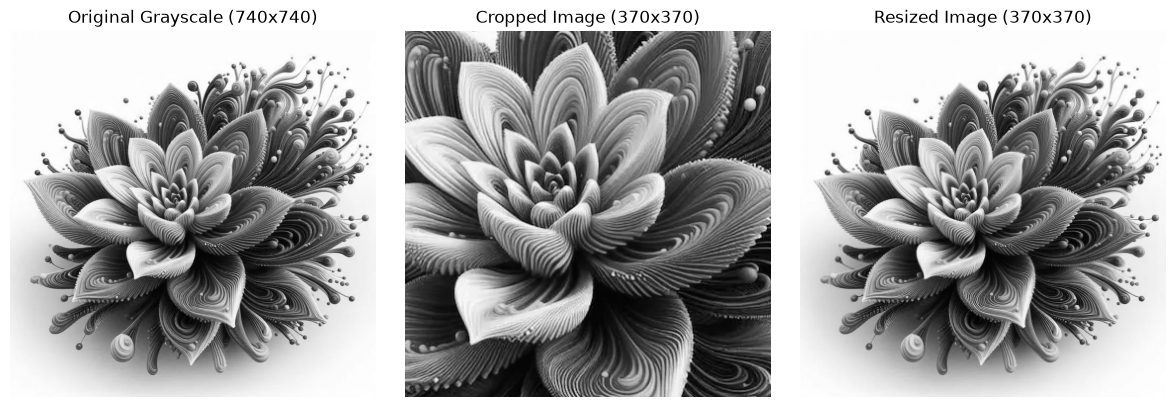

In [12]:
h, w = gray.shape

# Crop central region
cropped_img = gray[h//4:3*h//4, w//4:3*w//4]

# Resize to half width and height
resized_img = cv2.resize(gray, (w // 2, h // 2))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title(f'Original Grayscale ({w}x{h})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cropped_img, cmap='gray')
plt.title(f'Cropped Image ({cropped_img.shape[1]}x{cropped_img.shape[0]})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(resized_img, cmap='gray')
plt.title(f'Resized Image ({resized_img.shape[1]}x{resized_img.shape[0]})')
plt.axis('off')

plt.tight_layout()
plt.show()


**Think:** Which operation changes the spatial dimensions? Does resizing necessarily create new image information?


## Part 12 — Add Salt-and-Pepper Noise
The following creates impulse noise by randomly changing some pixels to 0 or 255.


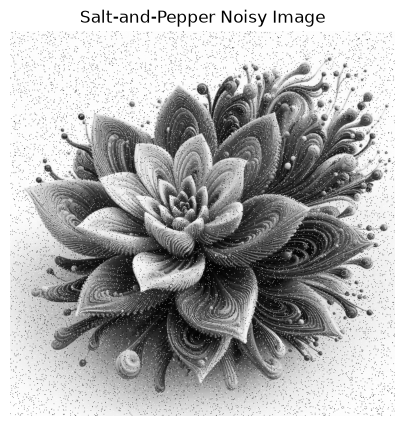

In [13]:
np.random.seed(42)
noisy_img = gray.copy()
prob = 0.05  # 5% impulse noise

rnd = np.random.rand(*gray.shape)
noisy_img[rnd < (prob / 2)] = 0         # Pepper (0)
noisy_img[(rnd >= (prob / 2)) & (rnd < prob)] = 255  # Salt (255)

plt.figure(figsize=(6, 5))
plt.imshow(noisy_img, cmap='gray')
plt.title('Salt-and-Pepper Noisy Image')
plt.axis('off')
plt.show()


## Part 13 — Mean vs Median Filtering
Now connect the experiment to order-statistic filtering.


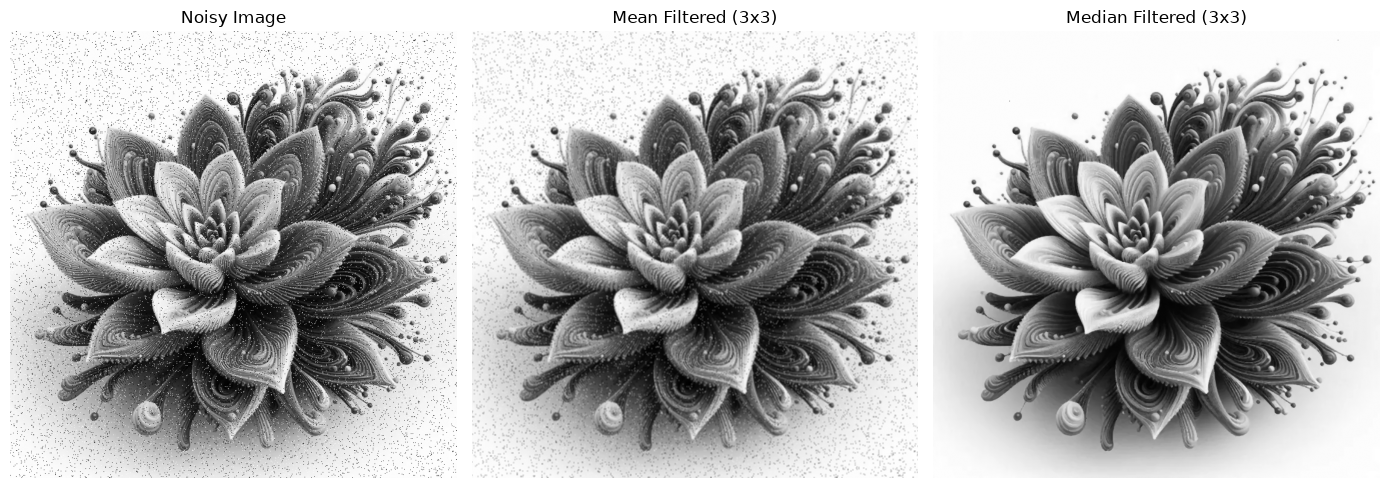

In [14]:
mean_filtered = cv2.blur(noisy_img, (3, 3))
median_filtered = cv2.medianBlur(noisy_img, 3)

plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mean_filtered, cmap='gray')
plt.title('Mean Filtered (3x3)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(median_filtered, cmap='gray')
plt.title('Median Filtered (3x3)')
plt.axis('off')

plt.tight_layout()
plt.show()


### Critical Thinking
Compare the noisy image, mean-filtered image and median-filtered image.
1. Which filter removes the salt-and-pepper noise more effectively?
2. Which filter preserves edges better?
3. Why can an extreme value such as 255 strongly affect the mean but have much less effect on the median?
4. What do you expect if the window is changed from 3×3 to 7×7?


## Part 14 — Manual Order-Statistic Exercise
Consider the following 3×3 neighborhood:

$$\begin{bmatrix} 42 & 43 & 44 \\ 43 & 255 & 45 \\ 44 & 45 & 46 \end{bmatrix}$$

Before running Python, calculate manually:
- Minimum
- Maximum
- Median
- Mean
- Midpoint

Then execute the following cell.


In [15]:
neighborhood = np.array([
    [42, 43, 44],
    [43, 255, 45],
    [44, 45, 46]
])

print('Neighborhood Matrix:\n', neighborhood)
print('---')
print('Minimum: ', np.min(neighborhood))
print('Maximum: ', np.max(neighborhood))
print('Median:  ', np.median(neighborhood))
print('Mean:    ', round(float(np.mean(neighborhood)), 2))
print('Midpoint:', (int(np.max(neighborhood)) + int(np.min(neighborhood))) / 2.0)


Neighborhood Matrix:
 [[ 42  43  44]
 [ 43 255  45]
 [ 44  45  46]]
---
Minimum:  42
Maximum:  255
Median:   44.0
Mean:     67.44
Midpoint: 148.5
